<h1 style="text-align:center;">Probability of Default Credit Risk Model Training</h1>

<h4>Libraries Used</h4>

In [1]:
import numpy as np # linear algebra 
import pandas as pd # data processing 
import matplotlib.pyplot as plt # data visualisation 
import seaborn as sns # more data visualisation
from datetime import datetime

from sklearn.impute import SimpleImputer, KNNImputer # Imputation Methods for missing values
from sklearn.model_selection import train_test_split # split data into train and test
from sklearn.preprocessing import MinMaxScaler # scale the data between 0 - 1
from sklearn.metrics import classification_report,confusion_matrix, ConfusionMatrixDisplay # Model Evaluation 
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,roc_auc_score)
import json

from tensorflow.keras.models import Sequential # for building the model 
from tensorflow.keras.layers import Dense, Activation, Dropout # add the layers
from tensorflow.keras.optimizers import Adam # optimizer 
from tensorflow.keras.callbacks import EarlyStopping, TensorBoard # Early Stopping and Tensor Board
from tensorflow.keras.models import load_model # load the model

from imblearn.under_sampling import RandomUnderSampler # Balance the Data

In [2]:
data = pd.read_csv(r"C:\Users\Admin\Desktop\Credit_Risk_Platform\data\lending_club_loan_data_cleaned.csv") #CLEANED DATA

In [3]:
# Create permanent id for every loan
# ensuring every loan can always be traced back later 
data.insert(0,"Loan_ID",range(1, len(data)+1))

In [4]:
# Save copy for dashboard
loan_data = data.copy()
loan_data.to_csv(r"C:\Users\Admin\Desktop\Credit_Risk_Platform\data\lending_club_loan_data_dashboard_copy.csv",index=False)

In [5]:
#loan_data.dtypes

<h2 style="text-align:center;">PREPROCESSING DATA FOR ALL PD MODEL</h2>

<p style="margin-bottom:0;"><b>0. Keep the ID for identification, but remove it from the model's learning data.</b></p>


In [6]:
#keep the ID
loan_ids = loan_data["Loan_ID"]

#Remove IDs before training 
loan_data = loan_data.drop("Loan_ID", axis=1)

<p><b>WHY?</b> If we leave it in, the neural network could potentially find meaningless numerical patterns in the IDs instead of learning from actual credit-risk variables</p>

<p style="margin-bottom:0;"><b>1. Encode Traget Variable</b></p>
<p>For the PD model, the target variable, loan_status, needs to be changed into numbers because the machine learning model works with numerical data, therefore, it is encoded into two values. 1 represents a loan that was not fully paid (default), while 0 represents a loan that was fully paid. </p>

In [7]:
#ENCODING TARGET VARIABLE - loan amount 
def targetVariable(x):
    if x=='Fully Paid':
        return 0
    return 1

In [8]:
loan_data['loan_status'] = loan_data['loan_status'].apply(targetVariable) #apply func to all target variable

<p><b>2. Convert Categorical Variables to Numeric</b></p>

In [9]:
#CONVERT ALL CATEGORICAL VARIABLES TO NUMERIC 
# Start by listing all columns that are currently non-numeric
loan_data.select_dtypes(['object']).columns

Index(['term', 'grade', 'sub_grade', 'home_ownership', 'verification_status',
       'issue_d', 'purpose', 'earliest_cr_line', 'initial_list_status',
       'application_type', 'address'],
      dtype='object')

<p><b>term</b></p>

In [10]:
# inspecting "term" variable 
loan_data['term'].value_counts() # the output shows there are only 2 possible loan terms

term
36 months    300023
60 months     93441
Name: count, dtype: int64

In [11]:
# converting "term" variable to numeric by only keeping the first 3 numbers in each term column
loan_data['term'] = loan_data['term'].apply(lambda term: int(term[:3]))

<p><b>grade</b></p>

In [12]:
#inspecting grade variable 
#Since every grade is already represented within sub_grade, keeping both variables would be redundant.
loan_data = loan_data.drop('grade',axis=1) # remove grade varaible 

In [13]:
#CREATE DUMMY VARIABLES from the sub_grade variable 
subgrade_dummies = pd.get_dummies(loan_data['sub_grade'],drop_first=True)
loan_data = pd.concat([loan_data.drop('sub_grade',axis=1),subgrade_dummies],axis=1)
#converts the categorical variable into multiple binary columns.

<p style="margin-bottom:0;"><b>verification_status, application_type, initial_list_status, purpose</b></p>
<p style="margin:0;">These variables need to be converted into dummy variables so they could be used by machine learning models.</p>

In [14]:
#create dummy variables
dummies = pd.get_dummies(loan_data[['verification_status', 'application_type','initial_list_status','purpose' ]],drop_first=True)
#drop original columns 
loan_data = loan_data.drop(['verification_status', 'application_type','initial_list_status','purpose'],axis=1)
loan_data = pd.concat([loan_data,dummies],axis=1)

<p><b>home_ownership</b></p>


In [15]:
loan_data['home_ownership'].value_counts() # output is 6 home ownership categories 

home_ownership
MORTGAGE    197109
RENT        158770
OWN          37443
OTHER          110
NONE            29
ANY              3
Name: count, dtype: int64

<p>Convert these to dummy variables, but replace NONE and ANY with OTHER, so that we end up with just 4 categories, MORTGAGE, RENT, OWN, OTHER</p>

In [16]:
#combine rare categories
loan_data['home_ownership']=loan_data['home_ownership'].replace(['NONE', 'ANY'], 'OTHER')
#create dummy variables
dummies = pd.get_dummies(loan_data['home_ownership'],drop_first=True)
#remove original column
loan_data = loan_data.drop('home_ownership',axis=1)
loan_data = pd.concat([loan_data,dummies],axis=1)

<p style="margin:0;"><b>address</b></p>
<p style="margin:0;">The address variable was removed because the full address is highly specific to individual borrowers and is not directly relevant to predicting default. Removing it reduces unnecessary complexity and helps the model focus on more meaningful credit-risk characteristics.</p>

In [17]:
loan_data = loan_data.drop('address', axis=1)

<p style="margin-bottom:0;"><b>issue_d</b></p>
<p style="margin:0;">The issue date variable was removed because it could introduce data leakage into the model. Data leakage occurs when a model uses information that would not be available at the time a lending decision is made. Therefore, this feature is dropped to ensure that the model is trained using only information available at the time of loan application.</p>

In [18]:
loan_data = loan_data.drop('issue_d',axis=1)

<p><b>earliest_cr_line</b></p>
<p>This variable records the month and year a borrower first opened a credit account.Since machine learning models cannot effectively use dates stored as text, the year is extracted and converted into a numerical feature. </p>

In [19]:
loan_data['earliest_cr_line'].value_counts()

earliest_cr_line
Oct-2000    2999
Aug-2000    2911
Oct-2001    2878
Aug-2001    2869
Nov-2000    2723
            ... 
Feb-1957       1
Sep-1961       1
Nov-1955       1
Aug-1962       1
Aug-1959       1
Name: count, Length: 683, dtype: int64

In [20]:
#extract 4 last characters from each date (the year) 
loan_data['earliest_cr_year'] = loan_data['earliest_cr_line'].apply(lambda date:int(date[-4:]))
loan_data = loan_data.drop('earliest_cr_line',axis=1)

In [21]:
#listing all columns that are currently non-numeric
loan_data.select_dtypes(['object']).columns

Index([], dtype='object')

In [22]:
#data.shape

<p>All categorical variables were successfully converted into numerical features using encoding and feature engineering techniques. As a result, the dataset now contains only numerical variables and is ready for machine learning model development.</p>

In [23]:
#set x and y variables to the values of the featues and label 
x = loan_data.drop('loan_status',axis=1).values
y = loan_data['loan_status'].values

<h2 style="text-align:center;">PD MODEL DEVELOPMENT Version1</h2>

<p style="text-align:center;">PD Model Version 1 is the baseline model developed to predict the Probability of Default (PD) for borrowers. The model was trained using the original dataset, and provides a starting point for evaluating the model's performance before applying further improvements</p>

<p><b>Split into train/test sets </b></p>

In [24]:
# Split the dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(x,y,test_size=0.20,random_state=101)

In [25]:
scaler = MinMaxScaler() #Create Scaler 
X_train = scaler.fit_transform(X_train) # Learn from training data & scale it 
X_test = scaler.transform(X_test) # Also scale test data 

In [26]:
# BUILDING BASELINE TENSORFLOW MODEL 
model_v1 = Sequential() #Create neural network 

model_v1.add(Dense(78, activation = 'relu')) #add 78 neruons 
model_v1.add(Dropout(0.2)) #drop 20%

model_v1.add(Dense(39, activation = 'relu')) # add 39 neurons 
model_v1.add(Dropout(0.2)) # drop 20%

model_v1.add(Dense(19, activation = 'relu')) # add 19 neurons 
model_v1.add(Dropout(0.2)) #drop 20%

model_v1.add(Dense(1, activation = 'sigmoid')) # Output probability of default

model_v1.compile(loss = 'binary_crossentropy', optimizer = 'adam');

In [27]:
model_v1.fit( X_train, y_train, #TRAIN model 
    epochs = 25, # train 25 times 
    batch_size = 256, # with 256 records at a time 
    validation_data = (X_test, y_test)); # Test the model 

Epoch 1/25
1230/1230 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.4726 - val_loss: 0.4574
Epoch 2/25
1230/1230 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.4610 - val_loss: 0.4563
Epoch 3/25
1230/1230 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.4591 - val_loss: 0.4565
Epoch 4/25
1230/1230 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.4576 - val_loss: 0.4554
Epoch 5/25
1230/1230 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.4565 - val_loss: 0.4548
Epoch 6/25
1230/1230 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.4558 - val_loss: 0.4551
Epoch 7/25
1230/1230 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.4552 - val_loss: 0.4545
Epoch 8/25
1230/1230 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.4546 - val_loss: 0.4542
Epoch 9/25
1230/1230 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.4542 - val_loss: 0.4538
Epoch 10/25
1230/1230 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.4541 - val_loss: 0.4544
Epoch 11/25
1230/1230 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.4538 - val_loss: 0.4535
Epoch 12/25
1230/1230 ━━━━━━━━

In [28]:
#SAVE FIRST VERSION OF THE BASELINE MODEL 
model_v1.save(r"C:\Users\Admin\Desktop\Credit_Risk_Platform\models\pd_baselinemodel_v1.keras")

<h2>EVALUATING pd_baslinemodel_v1 PERFORMACE</h2>

<p> To evaluate how well the first version of the PD model predicts whether a loan will default or not, a training loss vs validation loss graph is plotted. This helps show how well the model is learning and whether it is overfitting or underfitting. It also helps determine whether additional training is improving the model.</p>
<ul>
    <li><b>Training Loss (loss): </b>Indicates how many errors the model makes on the data it learns from.</li>
    <li><b>Validation Loss (val_loss): </b>Indicates how many errors the model makes on data it has never seen before.</li>
</ul>

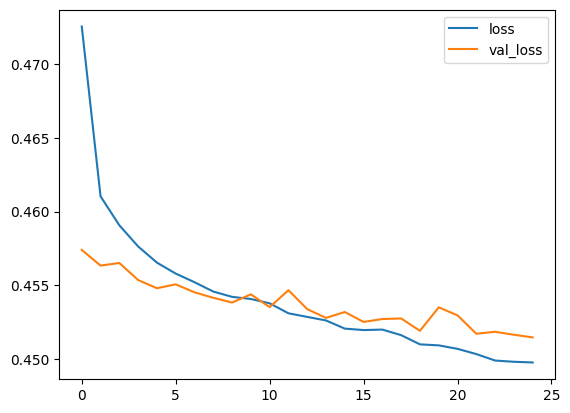

In [29]:
#Plot Validation loss Vs. the Training loss gragh 
losses = pd.DataFrame(model_v1.history.history) # store model 
losses[['loss','val_loss']].plot(); # plot model 

<p>The training and validation loss both decrease steadily and stay close to each other. This shows that the model is learning from the balanced data without overfitting. Overall, the model appears to generalise well to new borrowers.</p>

In [30]:
#MAKE CLASSIFICATION REPORT showing, Precision, Recall, F1-Score, Accuracy 
y_pred_v1 = model_v1.predict(X_test)
predictions_v1 = np.round(y_pred_v1).astype(int)
report_v1 = classification_report(y_test,predictions_v1,output_dict=True) #report dictionary 
# Display report
print(classification_report(y_test, predictions_v1))

2460/2460 ━━━━━━━━━━━━━━━━━━━━ 2s 898us/step
              precision    recall  f1-score   support

           0       0.81      0.99      0.89     63247
           1       0.55      0.05      0.09     15446

    accuracy                           0.81     78693
   macro avg       0.68      0.52      0.49     78693
weighted avg       0.76      0.81      0.73     78693



In [31]:
#SAVING METRICS FOR THE FIRST VERSION OF THE PD MODEL 
metrics_v1 = { "Accuracy": report_v1["accuracy"],"Precision": report_v1["1"]["precision"],"Recall": report_v1["1"]["recall"],"F1-Score": report_v1["1"]["f1-score"]}
with open("../outputs/model_metrics_v1.json", "w") as f:
    json.dump(metrics_v1, f, indent=4)

<p><b>Confusion Matrix</b></p>

2460/2460 ━━━━━━━━━━━━━━━━━━━━ 2s 926us/step


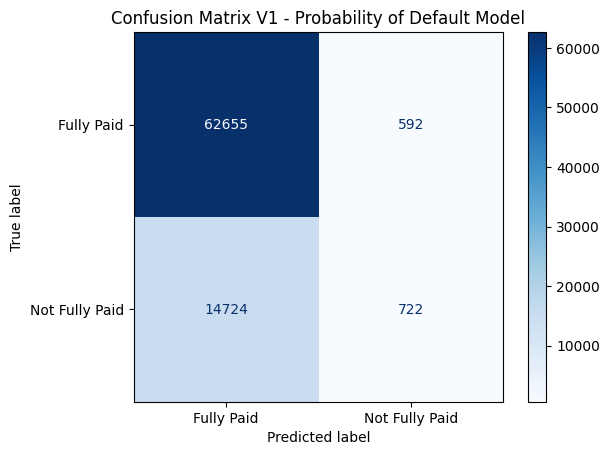

In [32]:
y_pred_prob_v1 = model_v1.predict(X_test)
y_pred_v1 = (y_pred_prob_v1 > 0.5).astype(int).flatten()

# Confusion Matrix
cm_v1 = confusion_matrix(y_test, y_pred_v1)
disp = ConfusionMatrixDisplay(
confusion_matrix=cm_v1,
display_labels=['Fully Paid', 'Not Fully Paid']
)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix V1 - Probability of Default Model')
plt.show()

<p>The confusion matrix shows that V1 was better at identifying Fully Paid loans but struggled with Not Fully Paid loans. It correctly identified 62,655 Fully Paid loans but only 722 Not Fully Paid loans, while missing 14,724 risky loans.</p>

<h3> Summary of PD BaselineModel Version 1</h3>
<p>The pd_baselinemodel_v1 achieved 80.54% accuracy, but its 4.67% recall and 8.62% F1-score show that it struggled to identify borrowers likely to default. The model mainly predicted Fully Paid loans because of the class imbalance in the data. Therefore, the training data needed to be balanced before developing the next model.</p>
<br>
<br>

<h2 style="text-align:center;">PD MODEL DEVELOPMENT Version2</h2>

<p style="text-align:center;">PD Model Version 2 was developed to improve the baseline model by addressing the class imbalance in the dataset. Random undersampling was used to create a more balanced dataset before training. This version was then evaluated to see whether balancing the classes improved the model's ability to identify borrowers who may default.</p>

In [35]:
# Both classes will have the same number of records (BALANCING)
rus = RandomUnderSampler(sampling_strategy=1,random_state=101)
X_res, y_res = rus.fit_resample(x, y)

In [36]:
# Split balanced data into training and testing sets
X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(X_res,y_res,test_size=0.20,random_state=101)

In [37]:
# Create scaler
scaler_v2 = MinMaxScaler()
# Fit scaler only on training data
X_train_v2 = scaler_v2.fit_transform(X_train_v2)
# Transform test data using the same scaler
X_test_v2 = scaler_v2.transform(X_test_v2)

In [38]:
#BUILD V2 model
model_v2 = Sequential()
model_v2.add(Dense(78, activation='relu'))
model_v2.add(Dropout(0.2))
model_v2.add(Dense(39, activation='relu'))
model_v2.add(Dropout(0.2))
model_v2.add(Dense(19, activation='relu'))
model_v2.add(Dropout(0.2))
model_v2.add(Dense(1, activation='sigmoid'))

#Complie model
model_v2.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

early_stop_v2 = EarlyStopping(monitor='val_loss',mode='min',verbose=1,patience=10,restore_best_weights=True)

#TRain model
history_v2 = model_v2.fit(
    X_train_v2,
    y_train_v2,
    epochs=25,
    batch_size=256,
    validation_data=(X_test_v2, y_test_v2),
    callbacks=[early_stop_v2]
)

Epoch 1/25
483/483 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6200 - loss: 0.6530 - val_accuracy: 0.6445 - val_loss: 0.6341
Epoch 2/25
483/483 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6407 - loss: 0.6391 - val_accuracy: 0.6452 - val_loss: 0.6330
Epoch 3/25
483/483 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6424 - loss: 0.6361 - val_accuracy: 0.6441 - val_loss: 0.6320
Epoch 4/25
483/483 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6460 - loss: 0.6343 - val_accuracy: 0.6438 - val_loss: 0.6317
Epoch 5/25
483/483 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6448 - loss: 0.6333 - val_accuracy: 0.6434 - val_loss: 0.6310
Epoch 6/25
483/483 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6457 - loss: 0.6321 - val_accuracy: 0.6474 - val_loss: 0.6289
Epoch 7/25
483/483 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6468 - loss: 0.6312 - val_accuracy: 0.6436 - val_loss: 0.6289
Epoch 8/25
483/483 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6475 - loss: 0.6302 - val_accuracy: 0.

In [68]:
#SAVE 2nd VERSION OF THE BASELINE MODEL 
model_v2.save(r"C:\Users\Admin\Desktop\Credit_Risk_Platform\models\pd_baselinemodel_v2.keras")

<h2>EVALUATING PD_BaselineModel_V2 PERFORMACE</h2>

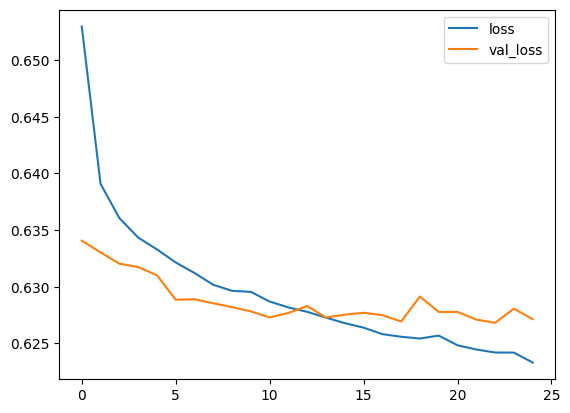

In [39]:
#Plot Validation loss Vs. the Training loss gragh 
losses = pd.DataFrame(model_v2.history.history) # store model 
losses[['loss','val_loss']].plot(); # plot model 

The training and validation loss both decrease steadily and stay close together. This shows that the model is learning well from the balanced data and is also performing consistently on unseen data. There are no major signs of overfitting, so the model can generalise better when identifying different levels of borrower risk.

In [40]:
#MAKE CLASSIFICATION REPORT showing, Precision, Recall, F1-Score, Accuracy 
y_pred_v2 = model_v2.predict(X_test_v2)
predictions_v2 = np.round(y_pred_v2).astype(int)
report_v2 = classification_report(y_test_v2,predictions_v2,output_dict=True) #report dictionary 
# Display report
print(classification_report(y_test_v2, predictions_v2))

965/965 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
              precision    recall  f1-score   support

           0       0.65      0.63      0.64     15365
           1       0.65      0.67      0.66     15513

    accuracy                           0.65     30878
   macro avg       0.65      0.65      0.65     30878
weighted avg       0.65      0.65      0.65     30878



In [41]:
#SAVING METRICS FOR THE FIRST VERSION OF THE PD MODEL 
metrics_v2 = { "Accuracy": report_v2["accuracy"],"Precision": report_v2["1"]["precision"],"Recall": report_v2["1"]["recall"],"F1-Score": report_v2["1"]["f1-score"]}
with open("../outputs/model_metrics_v2.json", "w") as f:
    json.dump(metrics_v2, f, indent=4)

<p><b>Confusion Matrix</b></p>

2460/2460 ━━━━━━━━━━━━━━━━━━━━ 2s 832us/step


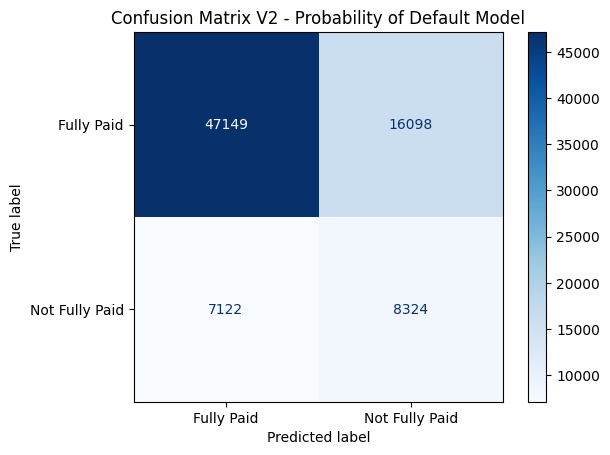

In [42]:
y_pred_prob_v2 = model_v2.predict(X_test)
y_pred_v2 = (y_pred_prob_v2 > 0.5).astype(int).flatten()

# Confusion Matrix
cm_v2 = confusion_matrix(y_test, y_pred_v2)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_v2,display_labels=['Fully Paid', 'Not Fully Paid'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix V2 - Probability of Default Model')
plt.show()

<p>The confusion matrix shows that V2 improved at identifying Not Fully Paid loans, correctly classifying 8,324 of them. However, it also incorrectly classified some Fully Paid loans as risky. Compared to V1, V2 is better for credit risk assessment because it identifies more borrowers who may default.</p>

<h3> Summary of PD BaselineModel Version 2</h3>
<p>The pd_baselinemodel_v2 achieved 65.00% accuracy, 64.58% precision, 67.19% recall, and an F1-score of 65.86%. Compared to V1, balancing the data greatly improved the model’s ability to identify borrowers who may default. Although the accuracy dropped, V2 was more balanced and less biased toward Fully Paid loans. The next step was to fine-tune the decision threshold to improve the balance between precision and recall.</p>
<br>
<br>

<h2 style="text-align:center;">PD MODEL Version2 - Decision Threshold Fine-Tuning</h2>

<p style="text-align:center;">This stage builds on PD Model V2 by testing different decision thresholds to find a better balance between precision and recall. The aim was to improve the model’s ability to identify borrowers who may default without retraining the model.</p>

In [43]:
#Get V2 Predicted PRobailities 
y_pred_prob_v2 = model_v2.predict(X_test_v2).flatten()
print(y_pred_prob_v2[:10])

965/965 ━━━━━━━━━━━━━━━━━━━━ 1s 987us/step
[0.40453398 0.65825963 0.9228876  0.54065347 0.55298173 0.6329299
 0.6345496  0.35827687 0.12333987 0.5794021 ]


In [44]:
#Test different classification Thresholds
thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]
#make dict
threshold_results = []

#testing 
for threshold in thresholds:
    predictions = (y_pred_prob_v2 >= threshold).astype(int)
    #calculate metrics
    precision = precision_score(y_test_v2, predictions)
    recall = recall_score(y_test_v2, predictions)
    f1 = f1_score(y_test_v2, predictions)
    #store
    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })
#dataframe for testing results
threshold_results_df = pd.DataFrame(threshold_results)
threshold_results_df

,Threshold,Precision,Recall,F1-Score
0,0.30,0.553965,0.928060,0.693798
1,0.35,0.577473,0.877135,0.696438
2,0.40,0.602258,0.811513,0.691399
3,0.45,0.625928,0.739186,0.677859
4,0.50,0.645787,0.671888,0.658579
5,0.55,0.664075,0.594598,0.627419
6,0.60,0.691050,0.493264,0.575641


In [69]:
#Save threshold results
threshold_results_df.to_csv(r"C:\Users\Admin\Desktop\Credit_Risk_Platform\outputs\threshold_results.csv",index=False)

In [62]:
#Best threshold 
best_threshold = 0.40

best_result = threshold_results_df[threshold_results_df["Threshold"] == best_threshold].iloc[0]
print("Selected Threshold:", best_threshold)
print("Precision:", best_result["Precision"])
print("Recall:", best_result["Recall"])
print("F1-Score:", best_result["F1-Score"])

Selected Threshold: 0.4
Precision: 0.6022580490838636
Recall: 0.8115129246438471
F1-Score: 0.6913993848857645


<b><p>The table shows the results from testing different classification thresholds on PD Model V2. The results show that when the threshold increases, precision generally increases while recall decreases. A threshold of 0.40 was selected because it provides a good balance between the two measures. At this threshold, the model achieved 60.23% precision and 81.15% recall, meaning it can identify a large number of borrowers who may default while keeping false positive predictions at a reasonable level. This makes the 0.40 threshold more suitable for the credit risk application.
</p></b>

In [63]:
#vcreate final v3 predctions
y_pred_v3 = (y_pred_prob_v2 >= best_threshold).astype(int)
print(y_pred_v3[:10])

[1 1 1 1 1 1 1 0 0 1]


<p><b>The final V3 predictions were created using the 0.40 threshold. A 1 means predicted default and 0 means predicted non-default. The next step is to calculate the model’s accuracy, precision, recall, F1-score, and ROC-AUC to evaluate its performance.</b></p>

In [64]:
# Calculate final V3 metrics
accuracy_v3 = accuracy_score(y_test_v2, y_pred_v3)
precision_v3 = precision_score(y_test_v2, y_pred_v3)
recall_v3 = recall_score(y_test_v2, y_pred_v3)
f1_v3 = f1_score(y_test_v2, y_pred_v3)

roc_auc_v3 = roc_auc_score(y_test_v2,y_pred_prob_v2)

<h2>EVALUATING PD_OptimisedModel PERFORMACE</h2>

In [65]:
print(classification_report(y_test_v2,y_pred_v3,target_names=['Fully Paid', 'Not Fully Paid']))

                precision    recall  f1-score   support

    Fully Paid       0.71      0.46      0.56     15365
Not Fully Paid       0.60      0.81      0.69     15513

      accuracy                           0.64     30878
     macro avg       0.65      0.64      0.62     30878
  weighted avg       0.65      0.64      0.62     30878



In [66]:
#save mterics 
metrics_v3 = {"Threshold": float(best_threshold),"Accuracy": float(accuracy_v3),"Precision": float(precision_v3),"Recall": float(recall_v3),"F1-Score": float(f1_v3),"ROC-AUC": float(roc_auc_v3)}
with open(r"C:\Users\Admin\Desktop\Credit_Risk_Platform\outputs\PD_OptimisedModel_metrics.json","w") as f:json.dump(metrics_v3,f,indent=4)

<p><b>confusion matrix</b></p>

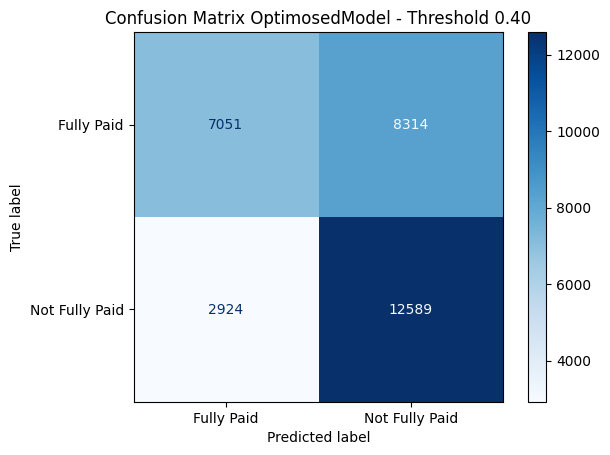

In [67]:
cm_v3 = confusion_matrix(y_test_v2,y_pred_v3)
disp_v3 = ConfusionMatrixDisplay(confusion_matrix=cm_v3,display_labels=['Fully Paid', 'Not Fully Paid'])

disp_v3.plot(cmap='Blues')
plt.title(f'Confusion Matrix OptimosedModel - Threshold 0.40')
plt.show()

<p>The optimised model with a 0.40 threshold was better at identifying Not Fully Paid loans, correctly detecting 12,589 of them. However, it also classified 8,314 Fully Paid loans as risky. Lowering the threshold made the model more cautious and helped reduce missed defaults. Although this created more false alarms, it is useful for credit risk because identifying potential defaulters is more important than avoiding every false positive.</p>

<h3> Summary of PD Optimised Model</h3>
<p>The PD Optimised Model used a 0.40 threshold instead of 0.50. It achieved 63.61% accuracy, 60.23% precision, 81.15% recall, and 69.14% F1-score, with a ROC-AUC of 0.704. The model was better at identifying potential defaulters, correctly detecting 12,589 Not Fully Paid loans. However, it also produced more false positives. Overall, the model gives more focus to detecting risky borrowers, which makes it more suitable for credit risk assessment.</p>
<br>
<br>

 <h2 style="text-align:center;">Generate Borrower Risk Scores for Power BI </h2>

<p style="text-align:center;">This section applies the selected 0.40 threshold to all borrowers in the dataset. It creates a separate dataset containing the Loan_ID, PD score, and Risk Category, which can then be used in Power BI to analyse individual borrowers and the overall loan portfolio.</p>

In [72]:
# V3 threshold selected from the previous analysis
v3_threshold = 0.40

#Prepare all records using the existing model features
X_all = scaler.transform(x)

#Generate PD scores for all borrowers
y_pred_prob_all = model_v2.predict(X_all)
pd_scores = y_pred_prob_all.flatten()

#Create df
borrower_scores = pd.DataFrame({"Borrower_ID": loan_ids.values,"PD_Score": pd_scores})

#apply V3 Threshold 
borrower_scores["Default_Prediction"] = (borrower_scores["PD_Score"] >= v3_threshold).astype(int)

#Create Risk Categories
def risk_category(pd_score):
    if pd_score < 0.10:
        return "Low Risk"
    elif pd_score < 0.40:
        return "Medium Risk"
    else:
        return "High Risk"
borrower_scores["Risk_Category"] = (borrower_scores["PD_Score"].apply(risk_category))

#round PD scores
borrower_scores["PD_Score"] = (borrower_scores["PD_Score"].round(3))

12296/12296 ━━━━━━━━━━━━━━━━━━━━ 51s 4ms/step


In [73]:
borrower_scores.shape

(393464, 4)

In [74]:
borrower_scores.head()

,Borrower_ID,PD_Score,Default_Prediction,Risk_Category
0,1,0.427,1,High Risk
1,2,0.343,0,Medium Risk
2,3,0.435,1,High Risk
3,4,0.091,0,Low Risk
4,5,0.587,1,High Risk


<p style="margin-bottom:0;"><b>Interpretation of the Borrower Risk Score Columns</b></p>
<ul style="margin:0;">
    <li><b>Borrower_ID:</b> Unique identifier used to identify each borrower.</li>
    <li><b>PD_Score:</b> The model's predicted probability that the borrower will default. Higher values indicate higher risk.</li>
    <li><b>Default_Prediction:</b> The final default classification using the selected 0.40 threshold. 1 indicates predicted default and 0 indicates predicted non-default.</li>
    <li><b>Risk_Category:</b> Groups borrowers into Low Risk, Medium Risk, or High Risk based on their PD score.</li>
</ul>

In [75]:
borrower_scores.to_csv(r"C:\Users\Admin\Desktop\Credit_Risk_Platform\outputs\borrower_risk_scores_.csv",index=False)